In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 │ ⚙️ CONFIG + LOAD DATASET (VIQUAD 2.0 VALIDATION - HUGGING FACE STREAMING)
# ─────────────────────────────────────────────────────────────────────────────
import os
import re
import unicodedata
from pathlib import Path
from datasets import load_dataset

MODEL_NAME = "/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/qwen3_examassist_merged_4b_rslora_domain_v3"

# Thay bằng repo ViQuAD 2.0 thực tế trên Hugging Face
HF_DATASET_NAME = "taidng/UIT-ViQuAD2.0" 

RANDOM_SEED = 42
MAX_NEW_TOKENS = 128
TEMPERATURE = 0.0
BATCH_SIZE = 8
MAX_MODEL_LEN = 2048
GPU_MEM_UTIL = 0.80

# ── Judge model (local, thay cho OpenAI API) ─────────────────────────────────
JUDGE_MODEL_NAME = "/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/Qwen3-8B"
JUDGE_MAX_MODEL_LEN = 4096
JUDGE_MAX_NEW_TOKENS = 768                   
JUDGE_GPU_MEM_UTIL = 0.80
JUDGE_BATCH_SIZE = 16

RUN_NAME = "qwen3_vl_4b_finetuned_viquad_test"

OUTPUT_DIR = Path(f"./benchmark_outputs/{RUN_NAME}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

# Định nghĩa chuỗi từ chối chuẩn cho câu hỏi không có câu trả lời
REFUSAL_GOLD = "Không có thông tin trong ngữ cảnh được cung cấp."

def normalize_text(text):
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"\s+", " ", text)
    return text

samples = []

# Load dataset ở chế độ streaming
dataset_stream = load_dataset(HF_DATASET_NAME, split="validation", streaming=True)

for row in dataset_stream:
    # Lấy các trường dữ liệu dựa theo schema chính xác
    qa_id = row.get("id", f"viquad_{len(samples)}")
    context = row["context"].strip()
    question = row["question"].strip()
    
    # Sử dụng trực tiếp trường is_impossible kiểu bool
    is_unanswerable = row.get("is_impossible", False) 
    
    # answers là dictionary, chuẩn HF thường có dạng: {'text': ['...'], 'answer_start': [...]}
    answers_dict = row.get("answers", {})
    answer_texts = answers_dict.get("text", [])
    
    gold_answers = []
    if is_unanswerable:
        # Nếu is_impossible == True, bỏ qua plausible_answers và dùng chuỗi từ chối
        gold_answer = REFUSAL_GOLD
        gold_answers = [REFUSAL_GOLD]
    else:
        # Xử lý an toàn phòng trường hợp is_impossible == False nhưng array answer_texts lại rỗng
        if len(answer_texts) > 0:
            gold_answers = [ans.strip() for ans in answer_texts]
            gold_answer = gold_answers[0]
        else:
            gold_answer = REFUSAL_GOLD
            gold_answers = [REFUSAL_GOLD]
            is_unanswerable = True
    
    system_msg = "Bạn là trợ lý AI hỗ trợ giải đáp thắc mắc. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Trả lời ngắn gọn, chính xác và không suy diễn ngoài dữ liệu."
    user_msg = f"Context: {context}\nQuestion: {question}"
    
    samples.append({
        "id": qa_id,
        "context": context,
        "question": question,
        "gold_answers": gold_answers,
        "gold_answer": gold_answer,
        "is_unanswerable": is_unanswerable,
        "messages": [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ]
    })
    
    # Bỏ comment cụm dưới nếu muốn test thử trước với 100 câu
    # if len(samples) >= 100:
    #     break

print("Loaded samples:", len(samples))
print("Example question:", samples[0]["question"])
print("Example gold:", samples[0]["gold_answer"])

/opt/miniconda3/envs/qwen3_bm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OUTPUT_DIR: /home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_finetuned_viquad_test


/opt/miniconda3/envs/qwen3_bm/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loaded samples: 3814
Example question: Paris đạt được thành quả gì sau khoảng 4 thế kỷ tính từ ngày Cách mạng Pháp diễn ra?
Example gold: trở thành một trong những trung tâm văn hóa của thế giới, thủ đô của nghệ thuật và giải trí


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 │ 🚀 LOAD QWEN3-VL-4B-INSTRUCT WITH vLLM (INFERENCE MODEL)
# ─────────────────────────────────────────────────────────────────────────────
import io
import sys
import os
import subprocess
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams

def _patch_jupyter_streams():
    _null_fd = os.open(os.devnull, os.O_WRONLY)

    class _FilenoPatchedStream:
        def __init__(self, original, null_fd):
            object.__setattr__(self, "_orig", original)
            object.__setattr__(self, "_null_fd", null_fd)

        def fileno(self):
            return object.__getattribute__(self, "_null_fd")

        def write(self, s):
            return object.__getattribute__(self, "_orig").write(s)

        def flush(self):
            return object.__getattribute__(self, "_orig").flush()

        def isatty(self):
            return False

        def readable(self):
            return False

        def writable(self):
            return True

        def __getattr__(self, name):
            return getattr(object.__getattribute__(self, "_orig"), name)

    for stream_name in ("stdout", "stderr"):
        stream = getattr(sys, stream_name)
        try:
            stream.fileno()
        except io.UnsupportedOperation:
            setattr(sys, stream_name, _FilenoPatchedStream(stream, _null_fd))

_patch_jupyter_streams()

print(subprocess.getoutput("nvidia-smi"))

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

llm = LLM(
    model=MODEL_NAME,
    trust_remote_code=True,
    dtype="half",
    quantization=None,
    max_model_len=MAX_MODEL_LEN,
    gpu_memory_utilization=GPU_MEM_UTIL,
    enforce_eager=True,
    max_num_seqs=BATCH_SIZE,
    limit_mm_per_prompt={"image": 0}
)

sampling_params = SamplingParams(
    temperature=TEMPERATURE,
    max_tokens=MAX_NEW_TOKENS
)

print("✅ Model loaded successfully.")

Mon Jul 20 22:24:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
| 60%   72C    P2            257W /  450W |   12654MiB /  24564MiB |     92%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

2026-07-20 22:24:42,657	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 07-20 22:24:42 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 07-20 22:24:42 [vllm.py:886] Asynchronous scheduling is enabled.
WARNING 07-20 22:24:42 [vllm.py:942] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 07-20 22:24:42 [vllm.py:960] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
INFO 07-20 22:24:42 [kernel.py:212] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=['vllm_c', 'native'])
INFO 07-20 22:24:42 [vllm.py:1135] Cudagraph is disabled under eager mode
INFO 07-20 22:24:42 [compilation.py:303] Enabled custom fusions: norm_quant, act_quant


[transformers] `Qwen2VLImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Qwen2VLImageProcessor` instead.
[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


(EngineCore pid=535189) INFO 07-20 22:24:46 [core.py:109] Initializing a V1 LLM engine (v0.21.0) with config: model='/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/qwen3_examassist_merged_4b_rslora_domain_v3', speculative_config=None, tokenizer='/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/qwen3_examassist_merged_4b_rslora_domain_v3', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, quantization_config=None, enforce_eager=True, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reason

(EngineCore pid=535189) Process EngineCore:
(EngineCore pid=535189) Traceback (most recent call last):
(EngineCore pid=535189)   File "/opt/miniconda3/envs/qwen3_bm/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
(EngineCore pid=535189)     self.run()
(EngineCore pid=535189)   File "/opt/miniconda3/envs/qwen3_bm/lib/python3.11/multiprocessing/process.py", line 108, in run
(EngineCore pid=535189)     self._target(*self._args, **self._kwargs)
(EngineCore pid=535189)   File "/opt/miniconda3/envs/qwen3_bm/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 1144, in run_engine_core
(EngineCore pid=535189)     raise e
(EngineCore pid=535189)   File "/opt/miniconda3/envs/qwen3_bm/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 1114, in run_engine_core
(EngineCore pid=535189)     engine_core = EngineCoreProc(*args, engine_index=dp_rank, **kwargs)
(EngineCore pid=535189)                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
(EngineCore pid

RuntimeError: Engine core initialization failed. See root cause above. Failed core proc(s): {}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 │ 🔮 INFERENCE
# ─────────────────────────────────────────────────────────────────────────────
import time
from tqdm import tqdm

prompts = []

for s in samples:
    prompt = tokenizer.apply_chat_template(
        s["messages"],
        tokenize=False,
        add_generation_prompt=True
    )
    prompts.append(prompt)

print("Total prompts:", len(prompts))
print("Prompt preview:")
print(prompts[0][:1000])

start_time = time.time()

outputs = llm.generate(
    prompts,
    sampling_params,
    use_tqdm=True
)

total_time = time.time() - start_time

predictions = [
    output.outputs[0].text.strip()
    for output in outputs
]

for s, pred in zip(samples, predictions):
    s["prediction"] = pred

print("✅ Inference completed")
print("Total time:", round(total_time, 2), "seconds")
print("Avg latency:", round(total_time / len(samples), 4), "sec/sample")
print("Throughput:", round(len(samples) / total_time, 2), "samples/sec")

print("\nPrediction example:")
print(predictions[0])

Total prompts: 430
Prompt preview:
<|im_start|>system
Bạn là trợ lý AI hỗ trợ giám thị coi thi. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Trả lời ngắn gọn, chính xác và không suy diễn ngoài dữ liệu.<|im_end|>
<|im_start|>user
Context:
Sự cố 01. Tài khoản đăng nhập EOS và quản lý mật khẩu. Trong kỳ thi EOS, mạng Wi-Fi sử dụng để làm bài là FU-Exam với mật khẩu FU-Exam@. Tài khoản đăng nhập hệ thống thi EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên. Do đó, nếu sinh viên quên mật khẩu đăng nhập EOS thì cần kiểm tra hoặc đặt lại mật khẩu tài khoản Wi-Fi FU-Student. Nếu sinh viên không nhớ mật khẩu Wi-Fi FU-Student, trước tiên cần kiểm tra hộp thư email bằng cách tìm kiếm các từ khóa như Wifi, EOS, IT, Account hoặc Pass để tìm email chứa thông tin tài khoản do nhà trường gửi. Nếu cần đổi mật khẩu, sinh viên truy cập http://reset.fun.cantho/, nhập tài khoản đăng nhập và địa chỉ email để nhận mật khẩu tạm thời. Sau khi nhận email, sinh viên quay lại trang reset, nhập Username, 

Processed prompts: 100%|██████████| 430/430 [00:20<00:00, 20.90it/s, est. speed input: 6736.84 toks/s, output: 635.68 toks/s]

✅ Inference completed
Total time: 20.77 seconds
Avg latency: 0.0483 sec/sample
Throughput: 20.71 samples/sec

Prediction example:
Tài khoản đăng nhập EOS là tài khoản Wi-Fi FU-Student của sinh viên.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 │ 🧹 GIẢI PHÓNG VRAM CỦA MODEL INFERENCE TRƯỚC KHI LOAD JUDGE MODEL
#            (bắt buộc để tránh OOM khi chạy 2 model vLLM tuần tự trên cùng 1 GPU)
# ─────────────────────────────────────────────────────────────────────────────
import gc
import torch

def unload_vllm(llm_instance):
    """Giải phóng toàn bộ VRAM đang bị vLLM giữ (weights + KV cache)."""
    try:
        from vllm.distributed.parallel_state import (
            destroy_model_parallel,
            destroy_distributed_environment,
        )
        destroy_model_parallel()
        destroy_distributed_environment()
    except Exception as e:
        print("Cảnh báo khi destroy vLLM parallel state:", e)

    try:
        del llm_instance.llm_engine.model_executor
    except Exception:
        pass

    del llm_instance
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

unload_vllm(llm)
del llm
gc.collect()
torch.cuda.empty_cache()

print("Đã giải phóng VRAM của model inference.")
print(subprocess.getoutput("nvidia-smi"))

Đã giải phóng VRAM của model inference.
Sat Jul 18 21:31:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
| 51%   60C    P2            171W /  450W |     872MiB /  24564MiB |    100%      Default |
|                                         |                        |                  N/A |
+-------

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 │ ⚖️ LOAD QWEN3-8B LÀM LLM JUDGE (local, thay cho gọi API)
# ─────────────────────────────────────────────────────────────────────────────
import inspect
from vllm import LLM as JudgeLLM, SamplingParams as JudgeSamplingParams
from pydantic import BaseModel, Field

class JudgeResult(BaseModel):
    # ĐƯA REASONING LÊN ĐẦU ĐỂ ÉP MÔ HÌNH SUY LUẬN TRƯỚC KHI CHẤM ĐIỂM (Chain-of-Thought)
    # Giữ lại field này vì nó ảnh hưởng trực tiếp tới chất lượng suy luận
    # và độ chính xác của các điểm số bên dưới.
    reasoning: str = Field(description="Phân tích và giải thích ngắn gọn (dưới 30 từ) lý do chấm điểm trước khi đưa ra kết quả.")

    is_refusal: bool = Field(description="True nếu mô hình từ chối trả lời vì thiếu thông tin trong ngữ cảnh.")
    is_hallucination: bool = Field(description="True nếu mô hình tự bịa ra thông tin không hề có trong ngữ cảnh (chỉ tính thông tin sai lệch, không tính diễn đạt khác).")
    faithfulness: float = Field(description="Độ trung thành với ngữ cảnh. Chỉ dùng các mức: 0.0 (bịa đặt hoàn toàn), 0.5 (có dựa vào ngữ cảnh nhưng suy diễn thêm), 1.0 (hoàn toàn dựa vào ngữ cảnh hoặc từ chối đúng vì ngữ cảnh không có).")

JUDGE_SCHEMA = JudgeResult.model_json_schema()

judge_tokenizer = AutoTokenizer.from_pretrained(
    JUDGE_MODEL_NAME,
    trust_remote_code=True
)

judge_llm = JudgeLLM(
    model=JUDGE_MODEL_NAME,
    trust_remote_code=True,
    dtype="half",
    max_model_len=JUDGE_MAX_MODEL_LEN,
    gpu_memory_utilization=JUDGE_GPU_MEM_UTIL,
    enforce_eager=True,
    max_num_seqs=JUDGE_BATCH_SIZE,
)

# Guided decoding: API đổi qua nhiều bản vLLM, nên tự dò thay vì import cứng.
def build_judge_sampling_params():
    try:
        from vllm.sampling_params import GuidedDecodingParams
        return JudgeSamplingParams(
            temperature=0.0,
            max_tokens=JUDGE_MAX_NEW_TOKENS,
            guided_decoding=GuidedDecodingParams(json=JUDGE_SCHEMA)
        )
    except ImportError:
        pass

    try:
        from vllm.model_executor.guided_decoding.guided_fields import GuidedDecodingParams
        return JudgeSamplingParams(
            temperature=0.0,
            max_tokens=JUDGE_MAX_NEW_TOKENS,
            guided_decoding=GuidedDecodingParams(json=JUDGE_SCHEMA)
        )
    except ImportError:
        pass

    if "guided_json" in inspect.signature(JudgeSamplingParams.__init__).parameters:
        return JudgeSamplingParams(
            temperature=0.0,
            max_tokens=JUDGE_MAX_NEW_TOKENS,
            guided_json=JUDGE_SCHEMA
        )

    print("⚠️ Phiên bản vLLM hiện tại không hỗ trợ guided decoding — "
          "sẽ ép JSON qua prompt, có fallback parser ở bước evaluation.")
    return JudgeSamplingParams(
        temperature=0.0,
        max_tokens=JUDGE_MAX_NEW_TOKENS
    )

judge_sampling_params = build_judge_sampling_params()

print("✅ Judge model loaded successfully.")

INFO 07-18 21:31:41 [utils.py:240] non-default args: {'trust_remote_code': True, 'dtype': 'half', 'max_model_len': 4096, 'gpu_memory_utilization': 0.8, 'max_num_seqs': 16, 'disable_log_stats': True, 'enforce_eager': True, 'model': '/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/Qwen3-8B'}
INFO 07-18 21:31:41 [model.py:568] Resolved architecture: Qwen3ForCausalLM
WARNING 07-18 21:31:41 [model.py:2035] Casting torch.bfloat16 to torch.float16.
INFO 07-18 21:31:41 [model.py:1697] Using max model len 4096
WARNING 07-18 21:31:41 [vllm.py:942] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 07-18 21:31:41 [vllm.py:960] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
INFO 07-18 21:31:41 [kernel.py:212] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_a

/opt/miniconda3/envs/qwen3_bm/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


(EngineCore pid=240817) INFO 07-18 21:31:45 [core.py:109] Initializing a V1 LLM engine (v0.21.0) with config: model='/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/Qwen3-8B', speculative_config=None, tokenizer='/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/Qwen3-8B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, quantization_config=None, enforce_eager=True, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config

Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  20% Completed | 1/5 [00:00<00:02,  1.50it/s]
Loading safetensors checkpoint shards:  40% Completed | 2/5 [00:01<00:02,  1.37it/s]
Loading safetensors checkpoint shards:  60% Completed | 3/5 [00:02<00:01,  1.39it/s]
Loading safetensors checkpoint shards:  80% Completed | 4/5 [00:02<00:00,  1.49it/s]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:03<00:00,  1.90it/s]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:03<00:00,  1.66it/s]
(EngineCore pid=240817) 


(EngineCore pid=240817) INFO 07-18 21:31:50 [default_loader.py:397] Loading weights took 3.04 seconds
(EngineCore pid=240817) INFO 07-18 21:31:50 [gpu_model_runner.py:4959] Model loading took 15.27 GiB memory and 3.141361 seconds
(EngineCore pid=240817) INFO 07-18 21:31:52 [gpu_worker.py:462] Available KV cache memory: 2.62 GiB
(EngineCore pid=240817) INFO 07-18 21:31:52 [kv_cache_utils.py:1710] GPU KV cache size: 19,088 tokens
(EngineCore pid=240817) INFO 07-18 21:31:52 [kv_cache_utils.py:1711] Maximum concurrency for 4,096 tokens per request: 4.66x
(EngineCore pid=240817) INFO 07-18 21:31:52 [kernel_warmup.py:44] Skipping FlashInfer autotune because it is disabled.
(EngineCore pid=240817) INFO 07-18 21:31:52 [jit_monitor.py:54] Kernel JIT monitor activated — Triton JIT compilations during inference will be logged as warnings.
(EngineCore pid=240817) INFO 07-18 21:31:52 [core.py:306] init engine (profile, create kv cache, warmup model) took 1.61 s
(EngineCore pid=240817) INFO 07-18 21

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 │ EVALUATION METRICS — LLM-AS-A-JUDGE (refusal / hallucination / faithfulness)
#            + RULE-BASED METRICS (EM / F1 / ROUGE-L / Containment / Context Recall / Token-Faithfulness)
# ─────────────────────────────────────────────────────────────────────────────

import os
import re
import json
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

REFUSAL_GOLD = "Không có thông tin trong ngữ cảnh được cung cấp."

def build_judge_prompt(context: str, question: str, gold: str, pred: str) -> str:
    return f"""Bạn là một giám khảo AI chuyên nghiệp, khách quan.
Nhiệm vụ: Đánh giá câu trả lời của [Mô hình] dựa trên [Ngữ cảnh] do hệ thống RAG cung cấp và [Đáp án chuẩn] của con người.

[Dữ liệu]
- Ngữ cảnh: {context}
- Câu hỏi: {question}
- Đáp án chuẩn: {gold}
- Mô hình trả lời: {pred}

[Tiêu chí chấm điểm khắt khe]
1. Về Từ chối (Refusal): Nếu mô hình nói rằng không có đủ thông tin để trả lời, set is_refusal = True.
2. Từ chối đúng (Expected Refusal): Nếu [Đáp án chuẩn] thể hiện việc không thể trả lời, và [Mô hình] cũng từ chối -> Đánh giá faithfulness = 1.0.
3. Ảo tưởng (Hallucination): Nếu [Mô hình] đưa ra chi tiết cụ thể (tên, số, quy định) KHÔNG xuất hiện trong [Ngữ cảnh], set is_hallucination = True và faithfulness = 0.0.

Hãy suy luận kỹ (reasoning) trước khi chốt điểm số. Chỉ trả về JSON đúng theo schema, không thêm văn bản khác.
"""

# ── Build tất cả prompt cho judge và gọi vLLM theo batch (thay cho ThreadPoolExecutor + API) ──
judge_chat_prompts = []
for s in samples:
    user_prompt = build_judge_prompt(
        s.get("context", ""), s["question"], s["gold_answer"], s["prediction"]
    )
    judge_chat_prompts.append(
        judge_tokenizer.apply_chat_template(
            [
                {"role": "system", "content": "Bạn là giám khảo AI tiếng Việt chuyên nghiệp, nghiêm ngặt và công tâm."},
                {"role": "user", "content": user_prompt}
            ],
            tokenize=False,
            add_generation_prompt=True
        )
    )

print("Đang chạy LLM Judge (local, batched) để chấm điểm...")
judge_outputs = judge_llm.generate(
    judge_chat_prompts,
    judge_sampling_params,
    use_tqdm=True
)

JUDGE_DEFAULTS = {
    "reasoning": "",
    "is_refusal": False,
    "is_hallucination": False,
    "faithfulness": 0.0
}

def parse_judge_output(raw_text: str) -> dict:
    text = raw_text.strip()
    text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text).strip()

    parsed = None
    try:
        parsed = json.loads(text)
    except Exception:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match:
            try:
                parsed = json.loads(match.group(0))
            except Exception:
                parsed = None

    if not isinstance(parsed, dict):
        parsed = {"reasoning": f"Lỗi parse JSON, raw output: {text[:200]}"}

    # đảm bảo đủ key kể cả khi model bỏ sót field
    result = dict(JUDGE_DEFAULTS)
    result.update(parsed)
    return result

judged_results = [
    parse_judge_output(o.outputs[0].text)
    for o in judge_outputs
]

# ── Text utilities ────────────────────────────────────────────────────────────
def normalize_text(text):
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(
        r"[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]",
        " ", text
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_gold_unanswerable(gold):
    return normalize_text(REFUSAL_GOLD) in normalize_text(gold)

# ── Standard QA metrics (rule-based, giữ nguyên) ──────────────────────────────
def compute_em(pred, gold):
    return int(normalize_text(pred) == normalize_text(gold))

def compute_f1(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def lcs_length(x, y):
    dp = [[0] * (len(y) + 1) for _ in range(len(x) + 1)]
    for i in range(1, len(x) + 1):
        for j in range(1, len(y) + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[-1][-1]

def compute_rouge_l(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    lcs = lcs_length(pred_tokens, gold_tokens)
    precision = lcs / len(pred_tokens)
    recall    = lcs / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def compute_containment(pred, gold, f1_threshold=0.8):
    pred_norm = normalize_text(pred)
    gold_norm = normalize_text(gold)
    if not gold_norm:
        return 0
    if gold_norm in pred_norm:
        return 1
    if compute_f1(pred, gold) >= f1_threshold:
        return 1
    return 0

# ── Rule-based Faithfulness (token-level precision so với context) ───────────
def compute_faithfulness(pred: str, context: str) -> float:
    pred_tokens    = normalize_text(pred).split()
    context_tokens = set(normalize_text(context).split())
    if not pred_tokens:
        return 1.0
    matched = sum(1 for t in pred_tokens if t in context_tokens)
    return matched / len(pred_tokens)

# ── Context Recall (token-level recall của gold so với context) ──────────────
def compute_context_recall(gold: str, context: str, gold_unanswerable: bool) -> float:
    if gold_unanswerable:
        return 1.0
    gold_tokens    = normalize_text(gold).split()
    context_tokens = set(normalize_text(context).split())
    if not gold_tokens:
        return 1.0
    matched = sum(1 for t in gold_tokens if t in context_tokens)
    return matched / len(gold_tokens)

# ── Main evaluation loop (rule-based metrics + LLM-judge metrics) ────────────
rows = []

for idx, s in enumerate(samples):
    pred             = s["prediction"]
    gold             = s["gold_answer"]
    gold_answers_all = s.get("gold_answers", [gold])
    context          = s.get("context", "")

    gold_unanswerable = s.get("is_unanswerable", is_gold_unanswerable(gold))
    answerable        = not gold_unanswerable

    judge             = judged_results[idx] or {}
    pred_refusal      = bool(judge.get("is_refusal", False))
    is_hallucination  = int(judge.get("is_hallucination", False))
    llm_faithfulness  = judge.get("faithfulness", 0.0)
    judge_reasoning   = judge.get("reasoning", "")

    rule_faithfulness = compute_faithfulness(pred, context)
    context_recall    = compute_context_recall(gold, context, gold_unanswerable)
    pred_tokens_count = len(tokenizer.encode(pred, add_special_tokens=False))

    if answerable:
        em          = max(compute_em(pred, g)          for g in gold_answers_all)
        f1          = max(compute_f1(pred, g)          for g in gold_answers_all)
        rouge_l     = max(compute_rouge_l(pred, g)     for g in gold_answers_all)
        containment = max(compute_containment(pred, g) for g in gold_answers_all)

        false_refusal   = int(pred_refusal)
        correct_refusal = 0
    else:
        em          = int(pred_refusal)
        f1          = 1.0 if pred_refusal else 0.0
        rouge_l     = 1.0 if pred_refusal else 0.0
        containment = 0

        false_refusal   = 0
        correct_refusal = int(pred_refusal)

    rows.append({
        "id":               s["id"],
        "question":         s["question"],
        "context":          context,
        "gold_answer":      gold,
        "gold_answers_all": json.dumps(gold_answers_all, ensure_ascii=False),
        "prediction":       pred,
        "pred_len_tokens":  pred_tokens_count,

        "is_answerable":    int(answerable),
        "is_unanswerable":  int(not answerable),
        "pred_refusal":     int(pred_refusal),

        # Rule-based standard metrics
        "em":               em,
        "f1":               f1,
        "rouge_l":          rouge_l,
        "containment":      containment,

        # Rule-based faithfulness / context recall
        "faithfulness":     rule_faithfulness,
        "context_recall":   context_recall,

        # LLM-as-judge metrics
        "llm_faithfulness": llm_faithfulness,
        "judge_reasoning":  judge_reasoning,

        "false_refusal":    false_refusal,
        "correct_refusal":  correct_refusal,
        "hallucination":    is_hallucination,

        "gold_len_words":   len(gold.split()),
        "pred_len_words":   len(pred.split())
    })

df = pd.DataFrame(rows)

answerable_df   = df[df["is_answerable"]   == 1]
unanswerable_df = df[df["is_unanswerable"] == 1]

summary = {
    "model":   MODEL_NAME,
    "judge_model": JUDGE_MODEL_NAME,
    "dataset": DATASET_PATH,
    "num_samples": len(df),
    "avg_pred_len_tokens": df["pred_len_tokens"].mean(),

    "answerable_samples":   len(answerable_df),
    "unanswerable_samples": len(unanswerable_df),

    # ── Rule-based standard metrics ──
    "overall_em":      df["em"].mean()      * 100,
    "overall_f1":      df["f1"].mean()      * 100,
    "overall_rouge_l": df["rouge_l"].mean() * 100,

    "answerable_em":          answerable_df["em"].mean()          * 100 if len(answerable_df) else 0,
    "answerable_f1":          answerable_df["f1"].mean()          * 100 if len(answerable_df) else 0,
    "answerable_rouge_l":     answerable_df["rouge_l"].mean()     * 100 if len(answerable_df) else 0,
    "answerable_containment": answerable_df["containment"].mean() * 100 if len(answerable_df) else 0,

    # ── LLM-as-judge metrics ──
    "overall_llm_faithfulness":      df["llm_faithfulness"].mean()          * 100,
    "answerable_llm_faithfulness":   answerable_df["llm_faithfulness"].mean() * 100 if len(answerable_df) else 0,
    "unanswerable_llm_faithfulness": unanswerable_df["llm_faithfulness"].mean() * 100 if len(unanswerable_df) else 0,

    # ── Rule-based (token-level) faithfulness & context recall ──
    "overall_faithfulness":        df["faithfulness"].mean()   * 100,
    "answerable_faithfulness":     answerable_df["faithfulness"].mean()   * 100 if len(answerable_df) else 0,
    "unanswerable_faithfulness":   unanswerable_df["faithfulness"].mean() * 100 if len(unanswerable_df) else 0,

    "overall_context_recall":      df["context_recall"].mean()      * 100,
    "answerable_context_recall":   answerable_df["context_recall"].mean() * 100 if len(answerable_df) else 0,
    "unanswerable_context_recall": unanswerable_df["context_recall"].mean() * 100 if len(unanswerable_df) else 0,

    # ── Refusal / Hallucination (đánh giá theo LLM-as-judge) ──
    "false_refusal_rate_answerable":     answerable_df["false_refusal"].mean() * 100 if len(answerable_df) else 0,
    "correct_refusal_rate_unanswerable": unanswerable_df["correct_refusal"].mean() * 100 if len(unanswerable_df) else 0,
    "hallucination_rate_unanswerable":   unanswerable_df["hallucination"].mean() * 100 if len(unanswerable_df) else 0,
    "hallucination_rate_overall":        df["hallucination"].mean() * 100,

    "avg_gold_len_words": df["gold_len_words"].mean(),
    "avg_pred_len_words": df["pred_len_words"].mean(),

    "total_inference_time_sec":   total_time,
    "avg_latency_sec":            total_time / max(len(df), 1),
    "throughput_samples_per_sec": len(df) / total_time if total_time > 0 else 0
}

summary_df = pd.DataFrame([summary])

print("\n===== BENCHMARK SUMMARY — LLM-AS-A-JUDGE + RULE-BASED METRICS =====")
display(summary_df)

print("\n===== KEY RESULTS =====")
print(f"Samples: {len(df)}")
print(f"Average prediction token length: {df['pred_len_tokens'].mean():.2f}")
print(f"Answerable:   {len(answerable_df)}")
print(f"Unanswerable: {len(unanswerable_df)}")
print()
print(f"Answerable EM:              {summary['answerable_em']:.2f}%")
print(f"Answerable F1:              {summary['answerable_f1']:.2f}%")
print(f"Answerable ROUGE-L:         {summary['answerable_rouge_l']:.2f}%")
print(f"Containment Accuracy:       {summary['answerable_containment']:.2f}%")
print(f"False Refusal Rate:         {summary['false_refusal_rate_answerable']:.2f}%")
print()
print(f"Correct Refusal Rate:  {summary['correct_refusal_rate_unanswerable']:.2f}%")
print(f"Hallucination Rate:    {summary['hallucination_rate_unanswerable']:.2f}%")
print()
print(f"Overall LLM Faithfulness:      {summary['overall_llm_faithfulness']:.2f}%")
print(f"Answerable LLM Faithfulness:   {summary['answerable_llm_faithfulness']:.2f}%")
print(f"Unanswerable LLM Faithfulness: {summary['unanswerable_llm_faithfulness']:.2f}%")
print()
print(f"Overall Faithfulness (rule-based):      {summary['overall_faithfulness']:.2f}%")
print(f"Answerable Faithfulness (rule-based):    {summary['answerable_faithfulness']:.2f}%")
print(f"Unanswerable Faithfulness (rule-based):  {summary['unanswerable_faithfulness']:.2f}%")
print()
print(f"Overall Context Recall:    {summary['overall_context_recall']:.2f}%")
print(f"Answerable Context Recall: {summary['answerable_context_recall']:.2f}%")
print()
print(f"Overall EM:               {summary['overall_em']:.2f}%")
print(f"Overall F1:               {summary['overall_f1']:.2f}%")

print("\n===== HALLUCINATION EXAMPLES (LLM-JUDGED) =====")
display(
    df[df["hallucination"] == 1][
        ["id", "question", "gold_answer", "prediction", "judge_reasoning"]
    ].head(10)
)

print("\n===== FALSE REFUSAL EXAMPLES (LLM-JUDGED) =====")
display(
    df[df["false_refusal"] == 1][
        ["id", "question", "gold_answer", "prediction", "judge_reasoning"]
    ].head(10)
)

print("\n===== LOW RULE-BASED FAITHFULNESS EXAMPLES (answerable, faithfulness < 0.3) =====")
display(
    answerable_df[answerable_df["faithfulness"] < 0.3][
        ["id", "question", "context", "gold_answer", "prediction", "faithfulness"]
    ].head(10)
)

Đang chạy LLM Judge (local, batched) để chấm điểm...


Rendering prompts:  29%|██▉       | 126/430 [00:00<00:00, 1253.12it/s]

(EngineCore pid=240817) WARNING 07-18 21:31:52 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _compute_slot_mapping_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Processed prompts: 100%|██████████| 430/430 [04:10<00:00,  1.72it/s, est. speed input: 1036.22 toks/s, output: 731.98 toks/s]


===== BENCHMARK SUMMARY — LLM-AS-A-JUDGE + RULE-BASED METRICS =====


...

,id,question,gold_answer,prediction,judge_reasoning
17,sample_17,Wi-Fi FU-Exam dùng tài khoản nào để đăng nhập?,Không có thông tin trong ngữ cảnh được cung cấp.,Tài khoản đăng nhập Wi-Fi FU-Exam là tài khoản...,
18,sample_18,Có thể đổi tên tài khoản đăng nhập EOS không?,Không có thông tin trong ngữ cảnh được cung cấp.,Không thể đổi tên tài khoản đăng nhập EOS. Tài...,
38,sample_38,Có được đổi sang mạng Wi-Fi cá nhân để thi không?,Không có thông tin trong ngữ cảnh được cung cấp.,"Không, sinh viên không được đổi sang mạng Wi-F...",
81,sample_81,Ai quyết định hình thức xử lý khi sinh viên vẫ...,Bộ phận Khảo thí xác nhận và quyết định hình t...,Giám thị quyết định hình thức xử lý khi sinh v...,
85,sample_85,Nếu giám thị chưa biết cách khởi động lại card...,Có thể tra cứu hướng dẫn hoặc nhờ Giám thị hàn...,Giám thị nên hướng dẫn sinh viên tự khởi động ...,
91,sample_91,Có thể nhờ ai hỗ trợ nếu chưa biết cách restar...,Có thể nhờ Giám thị hành lang hỗ trợ.,Giám thị có thể nhờ nhân viên kỹ thuật hoặc bộ...,
96,sample_96,Làm sao bật biểu tượng Wi-Fi trên Windows 11?,Không có thông tin trong ngữ cảnh được cung cấp.,Không liên quan đến ngữ cảnh xử lý lỗi thi EOS...,
107,sample_107,Khi nào cần tạo yêu cầu ReAssign?,"Khi máy tính tự tắt, sinh viên không nghe được...",Cần tạo yêu cầu ReAssign trong các trường hợp ...,
118,sample_118,Làm sao cài Microsoft Word?,Không có thông tin trong ngữ cảnh được cung cấp.,Không cài đặt Microsoft Word trong môi trường ...,
146,sample_146,Giám thị cần xác nhận điều gì trước khi cho si...,"Xác nhận sinh viên đã nộp bài thành công, ký x...",Giám thị cần xác nhận sinh viên đã:\n- Nộp bài...,



===== FALSE REFUSAL EXAMPLES (LLM-JUDGED) =====


,id,question,gold_answer,prediction,judge_reasoning
82,sample_82,"Trong trường hợp đặc biệt, sinh viên có thể đư...",Có. Bộ phận Khảo thí có thể quyết định cho phé...,Không có thông tin trong context đề cập đến hì...,
92,sample_92,Giám thị có thể tự học cách restart card mạng ...,Có thể tra cứu hướng dẫn trước khi thực hiện.,Không có hướng dẫn trong context cho phép giám...,



===== LOW RULE-BASED FAITHFULNESS EXAMPLES (answerable, faithfulness < 0.3) =====


,id,question,context,gold_answer,prediction,faithfulness
168,sample_168,Lỗi âm thanh khi thi nghe có nằm trong danh sá...,Yêu cầu chuẩn bị trước kỳ thi EOS. Để đảm bảo ...,Có. Lỗi âm thanh khi làm bài thi nghe là một t...,Có.,0.0


Saved fixed metrics:
benchmark_outputs/qwen3_vl_4b_baseline_domain_test/qwen_predictions_fixed_metrics.jsonl
benchmark_outputs/qwen3_vl_4b_baseline_domain_test/qwen_predictions_fixed_metrics.csv
benchmark_outputs/qwen3_vl_4b_baseline_domain_test/qwen_summary_fixed_metrics.csv
benchmark_outputs/qwen3_vl_4b_baseline_domain_test/qwen_summary_fixed_metrics.json


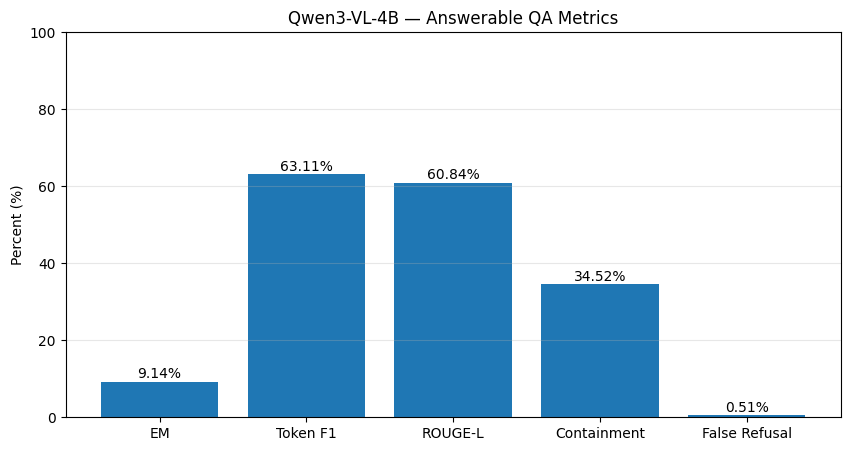

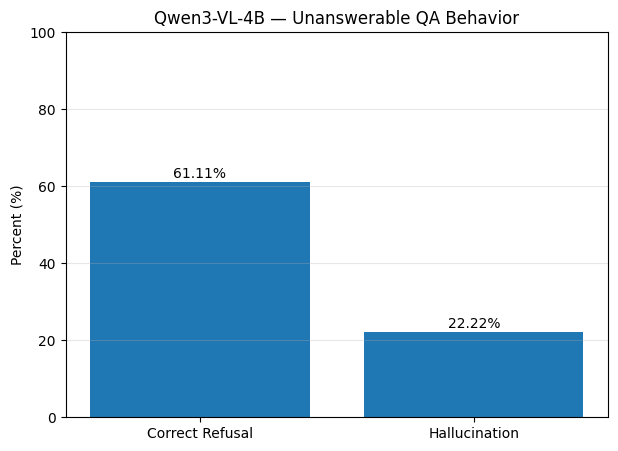

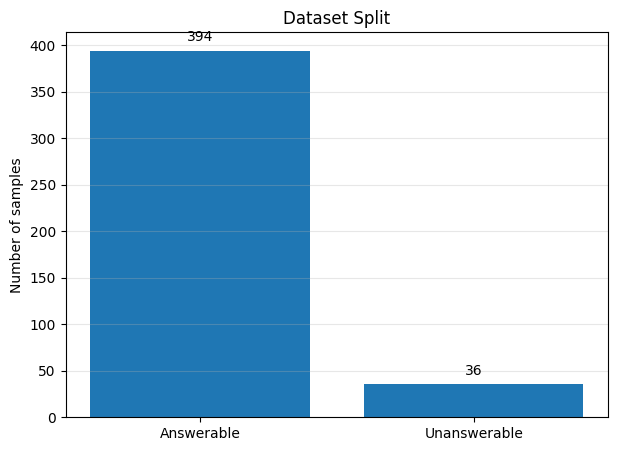

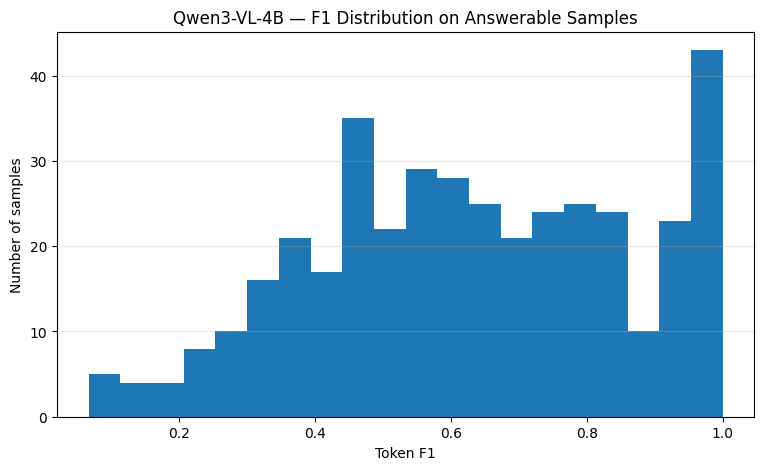


✅ Qwen fixed benchmark results saved to:
/home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_baseline_domain_test


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 │ 💾 SAVE RESULTS + CHARTS — QWEN FIXED BENCHMARK
# ─────────────────────────────────────────────────────────────────────────────
import json
import matplotlib.pyplot as plt

results_jsonl = OUTPUT_DIR / "qwen_predictions_fixed_metrics.jsonl"
results_csv = OUTPUT_DIR / "qwen_predictions_fixed_metrics.csv"
summary_csv = OUTPUT_DIR / "qwen_summary_fixed_metrics.csv"
summary_json = OUTPUT_DIR / "qwen_summary_fixed_metrics.json"

with open(results_jsonl, "w", encoding="utf-8") as f:
    for row in rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

df.to_csv(results_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved fixed metrics:")
print(results_jsonl)
print(results_csv)
print(summary_csv)
print(summary_json)

# Chart 1: Answerable QA metrics
metric_names = ["EM", "Token F1", "ROUGE-L", "Containment", "False Refusal"]
metric_values = [
    summary["answerable_em"],
    summary["answerable_f1"],
    summary["answerable_rouge_l"],
    summary["answerable_containment"],
    summary["false_refusal_rate_answerable"]
]

plt.figure(figsize=(10, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title("Qwen3-VL-4B — Answerable QA Metrics")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

chart_path = OUTPUT_DIR / "qwen_answerable_metrics.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 2: Unanswerable behavior
metric_names = ["Correct Refusal", "Hallucination"]
metric_values = [
    summary["correct_refusal_rate_unanswerable"],
    summary["hallucination_rate_unanswerable"]
]

plt.figure(figsize=(7, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title("Qwen3-VL-4B — Unanswerable QA Behavior")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

chart_path = OUTPUT_DIR / "qwen_unanswerable_behavior.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 3: Dataset split
split_names = ["Answerable", "Unanswerable"]
split_values = [
    summary["answerable_samples"],
    summary["unanswerable_samples"]
]

plt.figure(figsize=(7, 5))
plt.bar(split_names, split_values)
plt.ylabel("Number of samples")
plt.title("Dataset Split")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(split_values):
    plt.text(i, v + 10, str(v), ha="center")

chart_path = OUTPUT_DIR / "dataset_split.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 4: F1 distribution on answerable only
plt.figure(figsize=(9, 5))
plt.hist(answerable_df["f1"], bins=20)
plt.xlabel("Token F1")
plt.ylabel("Number of samples")
plt.title("Qwen3-VL-4B — F1 Distribution on Answerable Samples")
plt.grid(axis="y", alpha=0.3)

chart_path = OUTPUT_DIR / "qwen_answerable_f1_distribution.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("\n✅ Qwen fixed benchmark results saved to:")
print(OUTPUT_DIR.resolve())

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 │ 📝 SAVE QWEN FIXED BENCHMARK REPORT
# ─────────────────────────────────────────────────────────────────────────────

report_path = OUTPUT_DIR / "qwen_benchmark_report_fixed_metrics.md"

report = f"""# Benchmark Report — Qwen3-VL-4B-Instruct Baseline

## Model

`{MODEL_NAME}`

## Judge Model (local)

`{JUDGE_MODEL_NAME}`

## Dataset

`{DATASET_PATH}`

Number of samples: **{len(df)}**

- Answerable samples: **{summary["answerable_samples"]}**
- Unanswerable samples: **{summary["unanswerable_samples"]}**

## Main Results

### Answerable QA

| Metric | Value |
|---|---:|
| Answerable EM | {summary["answerable_em"]:.2f}% |
| Answerable Token F1 | {summary["answerable_f1"]:.2f}% |
| Answerable ROUGE-L | {summary["answerable_rouge_l"]:.2f}% |
| Containment Accuracy | {summary["answerable_containment"]:.2f}% |
| False Refusal Rate | {summary["false_refusal_rate_answerable"]:.2f}% |

### Unanswerable QA

| Metric | Value |
|---|---:|
| Correct Refusal Rate | {summary["correct_refusal_rate_unanswerable"]:.2f}% |
| Hallucination Rate on Unanswerable | {summary["hallucination_rate_unanswerable"]:.2f}% |

### Overall

| Metric | Value |
|---|---:|
| Overall EM | {summary["overall_em"]:.2f}% |
| Overall Token F1 | {summary["overall_f1"]:.2f}% |
| Overall ROUGE-L | {summary["overall_rouge_l"]:.2f}% |
| Average Latency | {summary["avg_latency_sec"]:.4f} sec/sample |
| Throughput | {summary["throughput_samples_per_sec"]:.2f} samples/sec |

## Interpretation

This benchmark follows a SQuAD2.0 / ViQuAD2.0-style evaluation because the dataset contains both answerable and unanswerable questions.

For answerable samples, EM, Token F1, ROUGE-L, and Containment Accuracy measure answer quality. Containment Accuracy is useful when the model generates a complete sentence while the gold answer is a short span.

For unanswerable samples, Correct Refusal Rate measures whether the model correctly refuses to answer when the context does not contain the answer. Hallucination Rate measures cases where the model produces an answer despite the gold label being unanswerable.

LLM-as-judge scoring (refusal / hallucination / faithfulness) is now performed locally with `{JUDGE_MODEL_NAME}` via vLLM instead of calling an external API.

## Output Files

- `qwen_predictions_fixed_metrics.jsonl`
- `qwen_predictions_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.json`
- `qwen_answerable_metrics.png`
- `qwen_unanswerable_behavior.png`
- `dataset_split.png`
- `qwen_answerable_f1_distribution.png`
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("✅ Qwen fixed report saved:")
print(report_path.resolve())

✅ Qwen fixed report saved:
/home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_baseline_domain_test/qwen_benchmark_report_fixed_metrics.md


In [ ]:
print(prompts[0])
print(predictions[0])

<|im_start|>system
Bạn là trợ lý AI hỗ trợ giám thị coi thi. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Trả lời ngắn gọn, chính xác và không suy diễn ngoài dữ liệu.<|im_end|>
<|im_start|>user
Context:
Sự cố 01. Tài khoản đăng nhập EOS và quản lý mật khẩu. Trong kỳ thi EOS, mạng Wi-Fi sử dụng để làm bài là FU-Exam với mật khẩu FU-Exam@. Tài khoản đăng nhập hệ thống thi EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên. Do đó, nếu sinh viên quên mật khẩu đăng nhập EOS thì cần kiểm tra hoặc đặt lại mật khẩu tài khoản Wi-Fi FU-Student. Nếu sinh viên không nhớ mật khẩu Wi-Fi FU-Student, trước tiên cần kiểm tra hộp thư email bằng cách tìm kiếm các từ khóa như Wifi, EOS, IT, Account hoặc Pass để tìm email chứa thông tin tài khoản do nhà trường gửi. Nếu cần đổi mật khẩu, sinh viên truy cập http://reset.fun.cantho/, nhập tài khoản đăng nhập và địa chỉ email để nhận mật khẩu tạm thời. Sau khi nhận email, sinh viên quay lại trang reset, nhập Username, Old Password (mật khẩu tạm thời), s

In [ ]:
df["gold_len_words"].describe()
df["pred_len_words"].describe()
low_f1 = df.sort_values("f1").head(20)

for _, row in low_f1.iterrows():
    print("="*20)
    print("QUESTION:", row["question"])
    print("GOLD    :", row["gold_answer"])
    print("PRED    :", row["prediction"])
    print("F1      :", row["f1"])

QUESTION: Làm thế nào để cập nhật Windows 11?
GOLD    : Không có thông tin trong ngữ cảnh được cung cấp.
PRED    : Không liên quan đến lỗi EOS. Cập nhật Windows 11:  
→ Mở **Settings** → **Windows Update** → Nhấn **Check for updates**.  
→ Tự động tải và cài đặt phiên bản mới nhất nếu có.  
→ Nếu không tự động, có thể cài đặt thủ công qua **Update & Security** → **Windows Update** → **Check for updates**.  

*Lưu ý: Cập nhật Windows 11 không giải quyết lỗi EOS, vì lỗi này liên quan đến phần mềm EOS, không phải hệ điều hành.*
F1      : 0.0
QUESTION: Wi-Fi FU-Exam dùng tài khoản nào để đăng nhập?
GOLD    : Không có thông tin trong ngữ cảnh được cung cấp.
PRED    : Tài khoản đăng nhập Wi-Fi FU-Exam là tài khoản Wi-Fi FU-Student của sinh viên.
F1      : 0.0
QUESTION: Có thể đổi tên tài khoản đăng nhập EOS không?
GOLD    : Không có thông tin trong ngữ cảnh được cung cấp.
PRED    : Không thể đổi tên tài khoản đăng nhập EOS. Tài khoản đăng nhập EOS chính là tài khoản Wi-Fi FU-Student, và tên 

In [ ]:
refusal_gold = 0

for s in samples:
    gold = s["gold_answer"].lower()

    if "tôi không tìm thấy thông tin" in gold:
        refusal_gold += 1

print("Unanswerable samples:", refusal_gold)
print("Answerable samples:", len(samples)-refusal_gold)
print("Refusal ratio:", refusal_gold/len(samples)*100)

Unanswerable samples: 0
Answerable samples: 430
Refusal ratio: 0.0
